## 1. Business Understanding

Tavoitteena on ennustaa asunnon neliöhintaa ("Y house price of unit area")
Taipein kaupungin kiinteistödatasta. Lisäksi rakennetaan toinen malli,
joka ennustaa, onko asunnon hinta yli vai alle keskiarvon (binäärinen
luokittelu).

Jos lineaarinen malli toimii hyvin, sitä voisi käyttää apuna
hinta-arvioissa. Logistista mallia voisi käyttää karkeampaan
"kallis vai ei" -luokitteluun.

## 2. Data Understanding

Data sisältää 414 riviä ja 6 featurea sekä yhden targetin
`Y house price of unit area`. Kaikki arvot ovat numeerisia,
eikä puuttuvia arvoja ole.

Featuret:
- X1 transaction date (aikaleima, esim. 2013.250 = maaliskuu 2013)
- X2 house age (vuosina)
- X3 distance to the nearest MRT station (metreinä)
- X4 number of convenience stores (kpl)
- X5 latitude (asteina)
- X6 longitude (asteina)

Target:
- Y house price of unit area (10 000 NT$/Ping)

In [47]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [48]:

from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
real_estate_valuation = fetch_ucirepo(id=477) 
  
# data (as pandas dataframes) 
X = real_estate_valuation.data.features 
y = real_estate_valuation.data.targets 
  
# metadata 
print(real_estate_valuation.metadata) 
  
# variable information 
print(real_estate_valuation.variables) 


{'uci_id': 477, 'name': 'Real Estate Valuation', 'repository_url': 'https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set', 'data_url': 'https://archive.ics.uci.edu/static/public/477/data.csv', 'abstract': 'The real estate valuation is a regression problem. The market historical data set of real estate valuation are collected from Sindian Dist., New Taipei City, Taiwan. ', 'area': 'Business', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 414, 'num_features': 6, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Y house price of unit area'], 'index_col': ['No'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2018, 'last_updated': 'Mon Feb 26 2024', 'dataset_doi': '10.24432/C5J30W', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 373, 'type': 'NATIVE', 'title': 'Building real estate valuation models with comparative approach through case-based reasoning', 'authors': 'I. Yeh

In [49]:
df = real_estate_valuation.data.features
df['Y house price of unit area'] = real_estate_valuation.data.targets['Y house price of unit area']

df.head()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [50]:
print(df.dtypes)
print()
print(df.isna().sum())


X1 transaction date                       float64
X2 house age                              float64
X3 distance to the nearest MRT station    float64
X4 number of convenience stores             int64
X5 latitude                               float64
X6 longitude                              float64
Y house price of unit area                float64
dtype: object

X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64


Katsotaan jokaisen featuren suhdetta hintaan hajontakaavioilla.
Näin nähdään, onko yhteys lineaarinen ja onko poikkeavia arvoja.

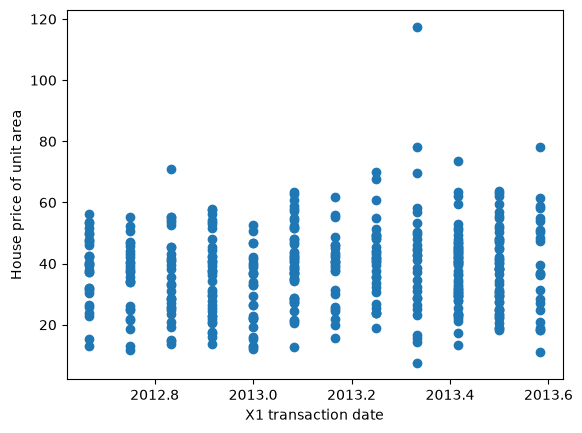

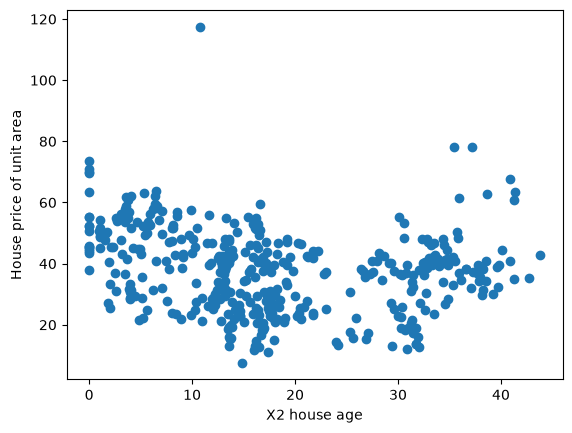

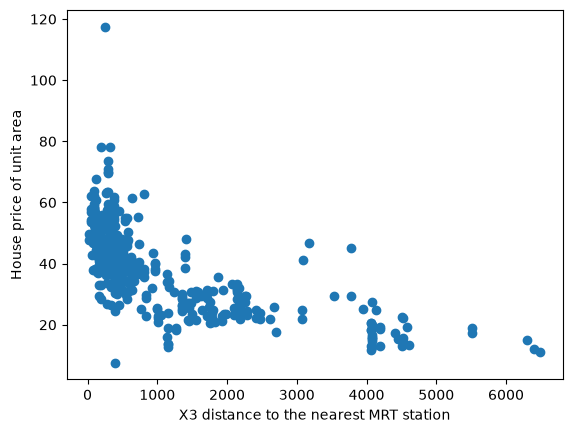

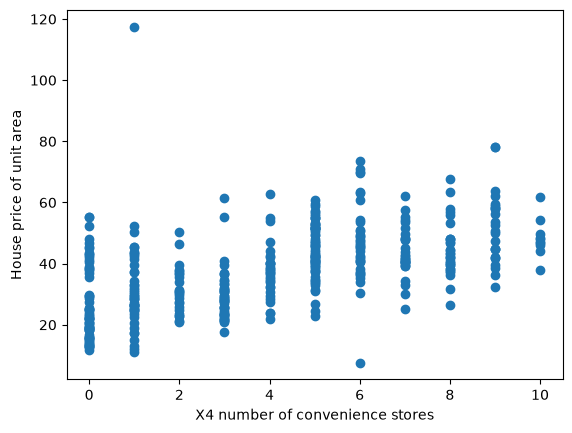

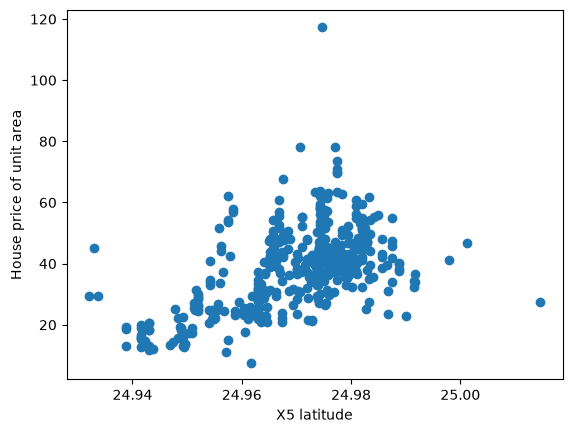

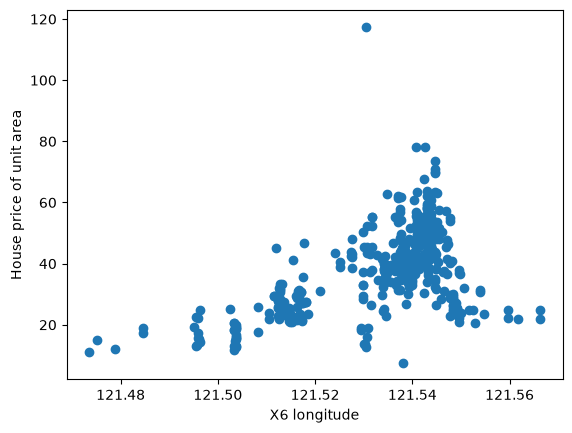

In [51]:
import matplotlib.pyplot as plt

X = df.drop(['Y house price of unit area'], axis=1)
y = df['Y house price of unit area']

for column in X.columns:
    plt.figure()
    plt.scatter(X[column], y)
    plt.xlabel(column)
    plt.ylabel('House price of unit area')
    plt.show()

## 3. Data Preparation

Jaetaan data train ja test-joukkoihin (80/20).
Näin mallia voidaan arvioida datalla, jota se ei ole nähnyt.

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=60
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (331, 6)
Test: (83, 6)


## 4. Modeling — Linear regression

Sovitetaan lineaarinen regressiomalli. Malli yrittää minimoida
keskineliövirheen (MSE) train-datalla.

In [54]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

b0 = model.intercept_ 
print("Intercept: %.2f" % b0)

print("Coefficients:")
for i in range(6):
    print("  %s: %.4f" % (X.columns[i], model.coef_[i]))

Intercept: -10605.24
Coefficients:
  X1 transaction date: 5.1876
  X2 house age: -0.2965
  X3 distance to the nearest MRT station: -0.0047
  X4 number of convenience stores: 1.0333
  X5 latitude: 253.2845
  X6 longitude: -50.3440


In [55]:
# Standardoidaan X 
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler_lin = StandardScaler()
X_train_scaled_lin = pd.DataFrame(
    scaler_lin.fit_transform(X_train), columns=X.columns
)

model_std = LinearRegression()
model_std.fit(X_train_scaled_lin, y_train)

# Järjestetään kertoimet itseisarvon mukaan
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coef_standardized': model_std.coef_,
    'abs_coef': abs(model_std.coef_)
}).sort_values('abs_coef', ascending=False).reset_index(drop=True)

print("Standardoidut kertoimet (tärkeysjärjestyksessä):")
print(coef_df.to_string(index=False))

Standardoidut kertoimet (tärkeysjärjestyksessä):
                               feature  coef_standardized  abs_coef
X3 distance to the nearest MRT station          -6.018488  6.018488
                          X2 house age          -3.410081  3.410081
                           X5 latitude           3.105544  3.105544
       X4 number of convenience stores           3.024157  3.024157
                   X1 transaction date           1.480741  1.480741
                          X6 longitude          -0.780803  0.780803


In [57]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("Mean absolute error: %.2f" % mae)
print("RMSE: %.2f" % rmse)
print("R²:   %.3f" % r2)

Mean absolute error: 5.91
RMSE: 8.14
R²:   0.624


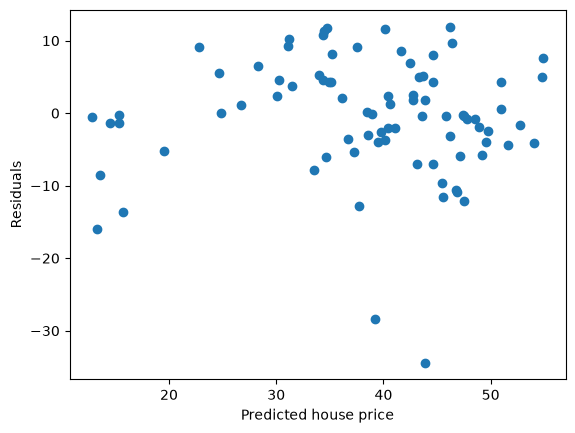

In [58]:
plt.scatter(preds, preds - y_test)
plt.xlabel('Predicted house price')
plt.ylabel('Residuals')
plt.show()

# 4. Modeling — Logistic regression

Target muutetaan binääriseksi: 1 jos hinnan neliöhinta on yli
train-joukon keskiarvon, muuten 0. Näin saadaan binäärinen
luokitteluongelma, johon logistic regression sopii.

In [59]:
import numpy as np

# muutetaan target binääriseksi train-keskiarvon perusteella
threshold = y_train.mean()
print("Train-keskiarvo (threshold): %.2f" % threshold)

y_train_bin = (y_train > threshold).astype(int)
y_test_bin = (y_test > threshold).astype(int)

Train-keskiarvo (threshold): 37.71


In [60]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

X_train_scaled.head()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
0,0.095491,1.906098,-0.365785,-0.707081,0.556542,0.079632
1,-1.656202,-0.476039,0.488823,-0.707081,-0.393619,-1.084180
2,0.971338,-1.554086,-0.703193,-1.390421,0.175662,-0.117023
3,0.971338,-1.162859,0.928448,-0.365411,-0.473546,-1.418817
4,0.971338,-0.067424,-0.092847,-0.023741,1.612728,0.036433


Sovitetaan logistic regression -malli standardoituun train-dataan.

In [61]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(solver='lbfgs', max_iter=1000)
logreg.fit(X_train_scaled, y_train_bin)

print("Intercept: %.4f" % logreg.intercept_[0])
print("Coefficients:")
for i, col in enumerate(X.columns):
    print("  %s: %.4f" % (col, logreg.coef_[0][i]))

Intercept: -0.6798
Coefficients:
  X1 transaction date: 0.3595
  X2 house age: -0.7851
  X3 distance to the nearest MRT station: -2.1125
  X4 number of convenience stores: 0.6015
  X5 latitude: 1.1264
  X6 longitude: 0.2546


Accuracy: 0.84
              precision    recall  f1-score   support

           0       0.87      0.77      0.82       197
           1       0.81      0.89      0.85       217

    accuracy                           0.84       414
   macro avg       0.84      0.83      0.83       414
weighted avg       0.84      0.84      0.83       414

Confusion Matrix:
 [[152  45]
 [ 23 194]]


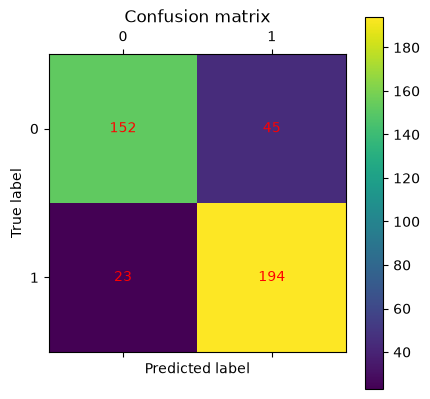

In [62]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

X_scaled = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)
y_bin = (y > y_train.mean()).astype(int)

y_pred_cv = cross_val_predict(estimator=logreg, X=X_scaled, y=y_bin, cv=10)

cm = confusion_matrix(y_bin, y_pred_cv)
accuracy = accuracy_score(y_bin, y_pred_cv)

print("Accuracy: %0.2f" % accuracy)
print(classification_report(y_bin, y_pred_cv))
print("Confusion Matrix:\n", cm)

plt.matshow(cm)
plt.title('Confusion matrix')
plt.colorbar()
plt.ylabel('True label')
plt.xlabel('Predicted label')
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='red')
plt.show()

# 5. Evaluation

**Lineaarinen regressio**

Malli selittää noin 62 % hinnan vaihtelusta (R² = 0.624).
MAE on 5.91 ja RMSE 8.14. Residuaalikaaviossa varianssi kasvaa
hinnan mukana (heteroskedastisuus), mikä rikkoo lineaarisen mallin
oletusta. Malli on silti käyttökelpoinen, mutta tuloksiin kannattaa
suhtautua varauksella.

**Logistic regression**

Malli luokittelee asunnot oikein noin 84 %:n tarkkuudella.
Standardoiduista kertoimista nähdään, että tärkein feature on
etäisyys MRT-asemalle (-2.11), toiseksi tärkein on latitude (1.13).
House age vaikuttaa negatiivisesti.

**Johtopäätös**

Molemmat mallit nostavat esiin samat featuret: etäisyys MRT-asemalle
ja sijainti (latitude) ovat tärkeimmät. Tämä on linjassa sen kanssa,
että asunnon sijainti on keskeinen hintaan vaikuttava tekijä.

# 6. Deployment

Lineaarista mallia voisi käyttää karkean hinta-arvion antamiseen
esimerkiksi kiinteistövälityssovelluksessa. Malli on kuitenkin
koulutettu vain Taipein alueen datalla, joten sitä ei voi suoraan
siirtää muille alueille.

Logistinen malli sopii "kallis vai ei" -tyyppiseen luokitteluun
esimerkiksi suodattimena, joka nostaa esiin kiinnostavat kohteet.

Molempia malleja pitäisi päivittää, kun uutta dataa kertyy.